Clustering and classification for features extracted from tiles modified with StainNet.

---
# 0. - Imports and paths

In [15]:
import os
import pandas as pd
import matplotlib.font_manager as fm
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
from PIL import Image, ImageDraw
import numpy as np
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.cluster import FeatureAgglomeration
from sklearn.decomposition import PCA#, TruncatedSVD
#import umap
import umap.umap_ as umap
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

In [16]:
os.chdir("/disk2/user/gabgam/work/gigi_env/the_project/4_clustering_and_classification/")
print(os.getcwd())

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification


In [17]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf or, better, https://fonts.google.com/specimen/DM+Sans
font_path = "../fonts/static/DMSans-Medium.ttf" 

# Add font to matplotlib
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'DM Sans'
except RuntimeError as e:
    print(f"Failed to load font: {e}")

In [18]:
model = "UNI2-h"

In [19]:
# PATH_TO_MERGED_PICKLES = f"output/{model}/satac_C1_v3_allspots_&_visium_2022_FF_WG_10X_img_not_changed_allspots/"
# COMPARISON = "satac_C1_v3_allspots_&_visium_2022_FF_WG_10X_img_not_changed_allspots"

# SELECTED_PICKLE_100um = 'MERGED_satac_C1_&_v3_allspots__&__visium_2022_FF_WG_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_stainNET.pickle'
# SELECTED_PICKLE_68um = 'MERGED_satac_C1_&_v3_allspots__&__visium_2022_FF_WG_10X_&_img_not_changed_allspots__for__target_is_reference_full_68um_stainNET.pickle'

In [20]:
PATH_TO_MERGED_PICKLES = f"output/{model}/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/"
COMPARISON = "satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots"

SELECTED_PICKLE_100um = 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_stainNET.pickle'
SELECTED_PICKLE_68um = 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_68um_stainNET.pickle'

In [21]:
# path to the target image
PATH_TO_REFERENCE = "../2_image_normalisation/reference_images/reference_full.jpeg"
# `TARGET_IS_<filename>`
TARGET_IS = "target_is_reference_full"

Defining the path to the figures.

In [22]:
PATH_TO_FIGURES = f"figures/{model}/{COMPARISON}"
os.makedirs(PATH_TO_FIGURES, exist_ok=True)

# 1. - Importing the extracted features

First of all, let's see all the MERGED `.pickle` files inside the folder of the saved features.

In [23]:
all_pickle_names = [i for i in os.listdir(PATH_TO_MERGED_PICKLES) if i.endswith('.pickle')]

print(f"{len(all_pickle_names)} .pickle files inside the folder.\n")
print(all_pickle_names)

8 .pickle files inside the folder.

['MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_ORIGINAL WSI.pickle', 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.pickle', 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_histomicsTK_macenko_nomasking.pickle', 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_100um_stainNET.pickle', 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_68um_ORIGINAL WSI.pickle', 'MERGED_satac_C1_&_v3_allspots__&__visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots__for__target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.pickle', 'MERGED_satac_C1_&_v3_alls

And let's choose the first file to visualise and extract the normalisation name from it.

In [24]:
TILE_SIZE = 100
SPOT_SIZE = 68

# Extractin the normalisation name from just one of it. They are the same in the end
# Find the pattern matching "<number>um_", the normalisation name is after it.
match = re.search(r"\d+um_", SELECTED_PICKLE_100um)

if match:
    # Extract everything after "<number>um_", remove the file type name and replace eventually present underscores with spaces.
    normalisation_name = SELECTED_PICKLE_100um.split(match.group())[-1].split(".")[0].replace("_", " ")
else:
    print("Wrong file inserted, no normalisation name found.")

print(normalisation_name)

stainNET


In [25]:
from utils_clust_n_class import load_pickle_as_df

merged_selected_pickle_df_100um = load_pickle_as_df(os.path.join(PATH_TO_MERGED_PICKLES, SELECTED_PICKLE_100um))
merged_selected_pickle_df_100um

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
AAACAAGGGATCAAAT_row31_col71_100um_stainNET_StainNET.jpg,-0.033423,0.589066,-0.134332,-0.069020,-0.076696,-0.770055,0.012218,-0.395377,0.280108,0.370694,...,-0.274948,0.031574,0.049260,0.373316,-0.221649,-0.278152,-0.725245,-0.557168,-0.431084,0.014018
AAACAGCAGTCTGCTA_row46_col32_100um_stainNET_StainNET.jpg,-0.438272,0.273205,-0.391030,-0.057215,0.302720,-0.709600,-0.267263,-0.959007,0.226993,0.198135,...,-0.300073,-0.171917,0.240682,0.166354,-0.016883,0.287547,-0.368897,-0.573093,0.271210,0.414324
AAACATTCGGGATTCT_row46_col22_100um_stainNET_StainNET.jpg,-0.132595,0.195348,-0.252739,-0.066557,0.105471,-0.523216,-0.112800,-1.029253,0.300439,0.113934,...,0.210925,-0.358305,0.164394,0.142669,-0.077925,-0.021934,-0.442636,-0.470326,-0.280242,-0.042862
AAACCTGGCACACCCT_row21_col33_100um_stainNET_StainNET.jpg,-0.143234,-0.231655,0.384484,-0.004440,-0.030816,-0.353873,-0.085034,-0.404443,0.172420,0.356898,...,-0.464531,-0.241978,0.149451,0.209409,-0.102156,0.031260,-0.475580,-0.494541,-0.248831,0.087503
AAACGCGGCGAAAGTA_row38_col90_100um_stainNET_StainNET.jpg,-0.245308,0.649397,0.018120,-0.097308,0.057878,-0.654822,0.295820,-0.761968,0.448445,0.115693,...,-0.480690,-0.245212,0.269498,0.354504,-0.294617,-0.430894,-0.784309,-0.486899,-0.425926,0.546650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCCCTGAGGATGGGCT-1_row68_col74_100um_stainNET.jpg,-0.330629,-0.544133,0.078692,0.143993,-0.067425,-0.521927,0.020633,-0.013075,0.348553,0.169392,...,-0.338637,-0.065412,0.572111,0.198063,0.442270,0.107888,-0.612202,0.280429,0.543738,-0.826788
CGGGCGATGGATCACG-1_row69_col75_100um_stainNET.jpg,0.193643,-0.654369,0.141311,0.000917,-0.163774,-0.008973,-0.088393,-0.514457,0.102083,0.226579,...,-0.105687,0.364746,0.116191,-0.036552,0.295452,0.130000,-0.502863,-0.277510,-0.079036,0.060978
TGCGGACTTGACTCCG-1_row68_col76_100um_stainNET.jpg,0.303627,-0.045448,-0.116704,0.031021,0.209364,-0.491832,-0.278926,-0.268984,-0.233316,0.503817,...,-0.183445,0.117692,0.013180,0.378343,0.141786,-0.395796,-0.215972,0.079795,0.165846,-0.153140
TCGCTGCCAATGCTGT-1_row68_col80_100um_stainNET.jpg,0.011498,-0.421936,0.305015,-0.117768,-0.326145,-0.835958,0.028418,-0.040429,0.199985,0.186679,...,0.163679,0.074643,0.011384,0.301555,0.307177,-0.227334,-0.205610,-0.362512,-0.310682,-0.003529


In [26]:
from utils_clust_n_class import load_pickle_as_df

merged_selected_pickle_df_68um = load_pickle_as_df(os.path.join(PATH_TO_MERGED_PICKLES, SELECTED_PICKLE_68um))
merged_selected_pickle_df_68um

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
CCGACCACCCTACGCG_row0_col0_68um_stainNET.jpg,-0.040355,0.011176,-0.171505,-0.117437,0.134034,-0.336765,-0.045594,-0.856168,0.329597,0.410358,...,-0.399251,-0.239350,-0.033303,0.048765,-0.016210,0.147360,-0.434779,-0.182371,0.065934,0.223421
AAGCCATAGTCGCGAC_row1_col1_68um_stainNET.jpg,-0.103129,0.462296,-0.107971,-0.142071,-0.002877,-0.670711,-0.067777,-0.563453,0.014459,0.189354,...,-0.110098,-0.314159,-0.329310,0.272559,-0.109740,0.135087,-0.217231,-0.251885,-0.491141,0.068081
TTGGGCGGACCGAAGC_row0_col2_68um_stainNET.jpg,-0.181745,0.402894,-0.093540,-0.089285,0.069179,-0.526511,-0.194443,-0.559690,0.300501,0.386626,...,-0.112141,-0.283085,0.230143,0.163252,-0.087932,0.276198,-0.751155,-0.325760,-0.208081,0.316896
AGTAAAGCGCATAATC_row1_col3_68um_stainNET.jpg,0.045683,0.068425,0.096123,-0.220025,0.046298,-0.192836,-0.085324,-0.785023,0.170747,0.389506,...,-0.565123,-0.509336,0.509911,0.237162,-0.046933,-0.167851,-0.573617,-0.616527,-0.398092,0.247451
CGACTCCGCCGATCAA_row0_col4_68um_stainNET.jpg,0.061904,-0.028368,-0.073345,-0.092944,-0.105242,-0.491636,-0.298038,-0.593388,0.158413,0.493568,...,-0.316278,-0.263120,-0.117282,-0.033270,-0.003127,0.644558,-0.462808,-0.100288,0.064103,0.493400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCCCTGAGGATGGGCT-1_row68_col74_68um_stainNET.jpg,-0.159512,-0.221446,-0.251624,-0.105198,-0.067194,-0.143690,0.172842,-0.175036,-0.006599,0.472736,...,-0.677777,-0.193283,0.235050,-0.226274,0.423913,-0.070287,-0.463629,0.291563,0.584292,-0.553079
CGGGCGATGGATCACG-1_row69_col75_68um_stainNET.jpg,0.150415,-0.692053,0.342158,-0.019074,-0.190731,0.347282,-0.082178,-0.751145,0.371283,0.322134,...,-0.317704,0.351682,-0.059505,-0.309911,0.325335,0.314552,-0.649035,-0.372793,0.037939,0.107572
TGCGGACTTGACTCCG-1_row68_col76_68um_stainNET.jpg,0.321544,0.109994,-0.155510,-0.115668,-0.029011,-0.471803,-0.192131,-0.269567,0.077423,0.670066,...,-0.557526,-0.327506,-0.320443,0.180860,0.236992,-0.551092,-0.453638,0.047685,0.253195,0.025387
TCGCTGCCAATGCTGT-1_row68_col80_68um_stainNET.jpg,-0.176859,-0.332783,0.235818,-0.049782,-0.350004,-0.592120,0.171278,-0.296466,-0.435717,0.392303,...,0.166903,-0.518825,-0.115993,0.209654,0.240601,-0.069083,-0.026254,-0.204335,-0.060747,-0.022593


# 2. - Dimensionality reduction

Let's plot the cumulative variance explained by the most important components.

## 2.1 - For 100 μm tiles

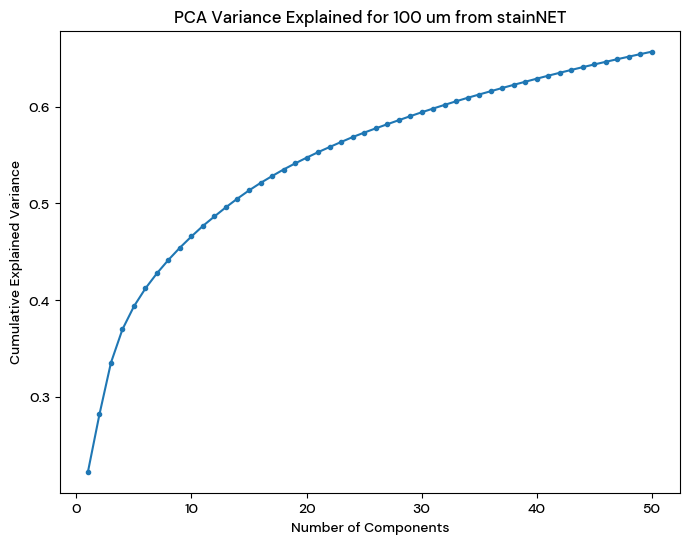

In [27]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot = pca_cumulative_variance_plot(merged_selected_pickle_df_100um, normalisation_name, TILE_SIZE)
plot.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')


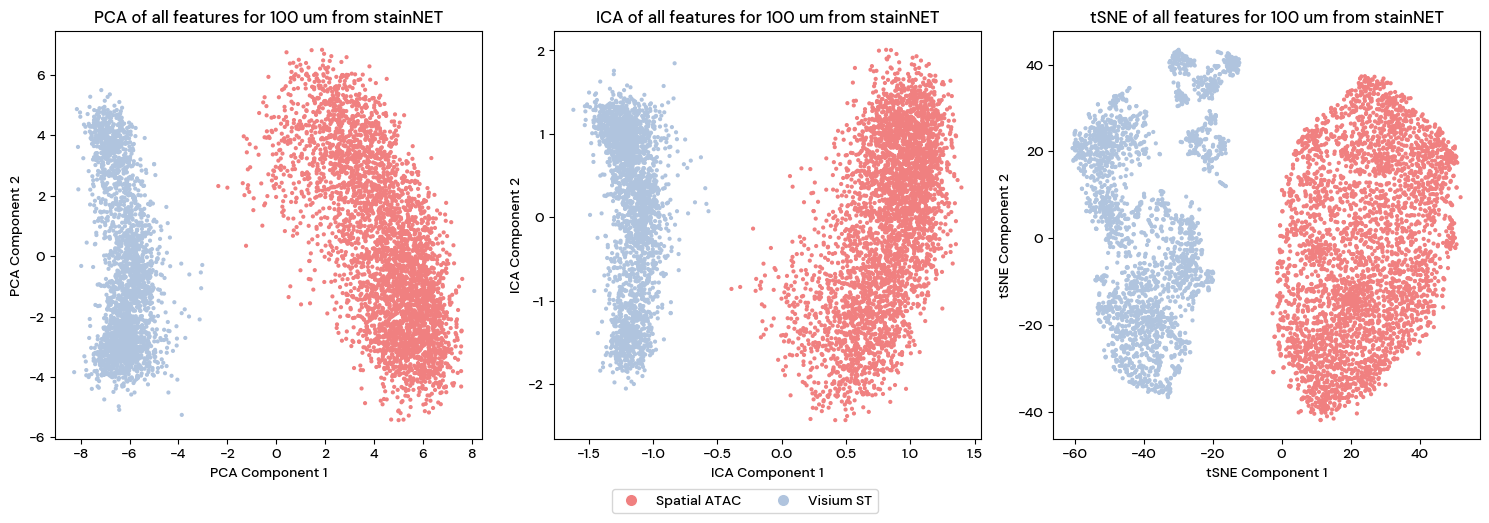

In [28]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot_100, dim_red_results_100 =  all_dim_red(merged_selected_pickle_df_100um, normalisation_name, COLORS_FOR_SPATIALS, TILE_SIZE, selected_methods = ["PCA", "ICA", "tSNE"])
plot_100.show()

In [29]:
plot_100.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{TILE_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"),
                format="PDF", bbox_inches='tight')

So, we can say that the normalisation is necessary.

---

## 2.2 - For 68 μm tiles

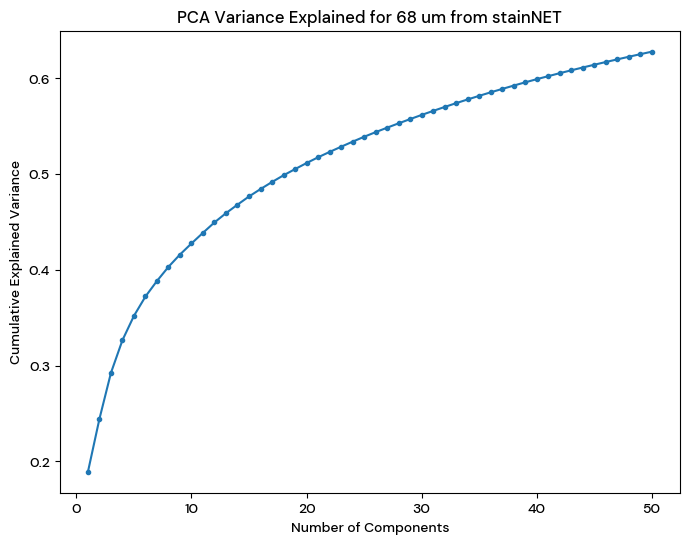

In [30]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot = pca_cumulative_variance_plot(merged_selected_pickle_df_68um, normalisation_name, SPOT_SIZE)
plot.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:159: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')


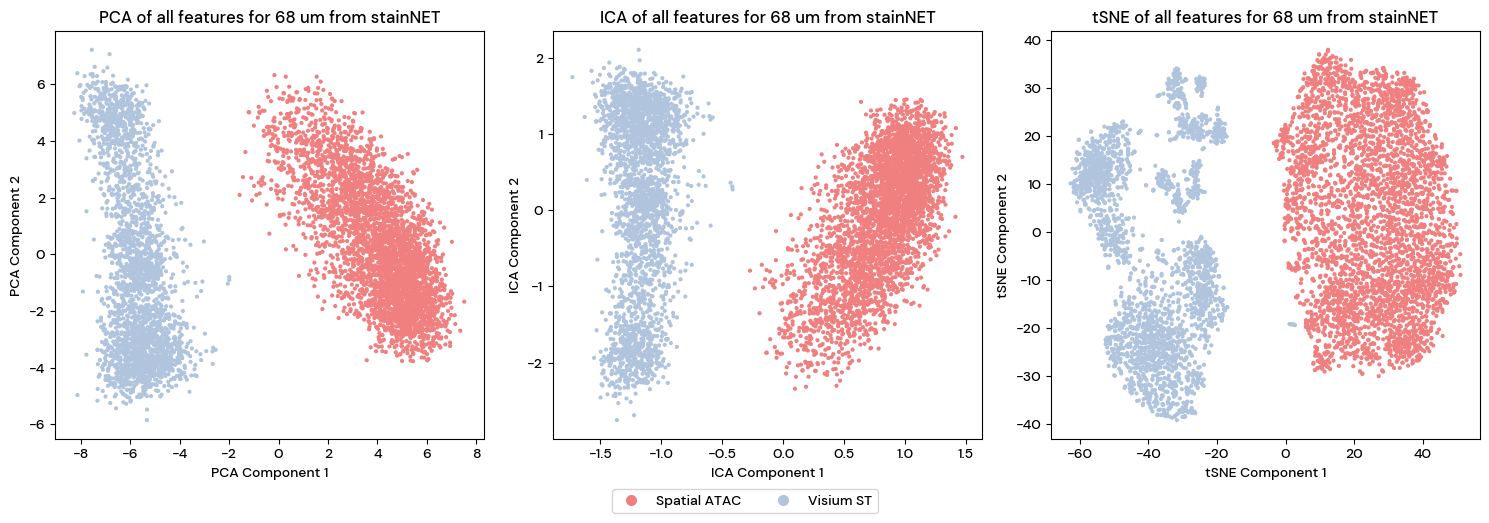

In [31]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot_68, dim_red_results_68 =  all_dim_red(merged_selected_pickle_df_68um, normalisation_name, COLORS_FOR_SPATIALS, SPOT_SIZE, selected_methods = ["PCA", "ICA", "tSNE"])
plot_68.show()

In [32]:
plot_68.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{SPOT_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"), 
                format="PDF", bbox_inches='tight')

So, we can say that the normalisation is necessary.

---

# 3. - Clustering

In [18]:
dim_red_results_100["PCA"]

array([[ 7.4599752 ,  2.8215885 ],
       [ 8.287314  , -0.01099305],
       [ 7.5920606 ,  0.40833068],
       ...,
       [-3.8559983 , -1.0735452 ],
       [-4.004223  , -4.761414  ],
       [-4.3771253 , -1.7236993 ]], dtype=float32)

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/tmp/ipykernel_218460/1340331449.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


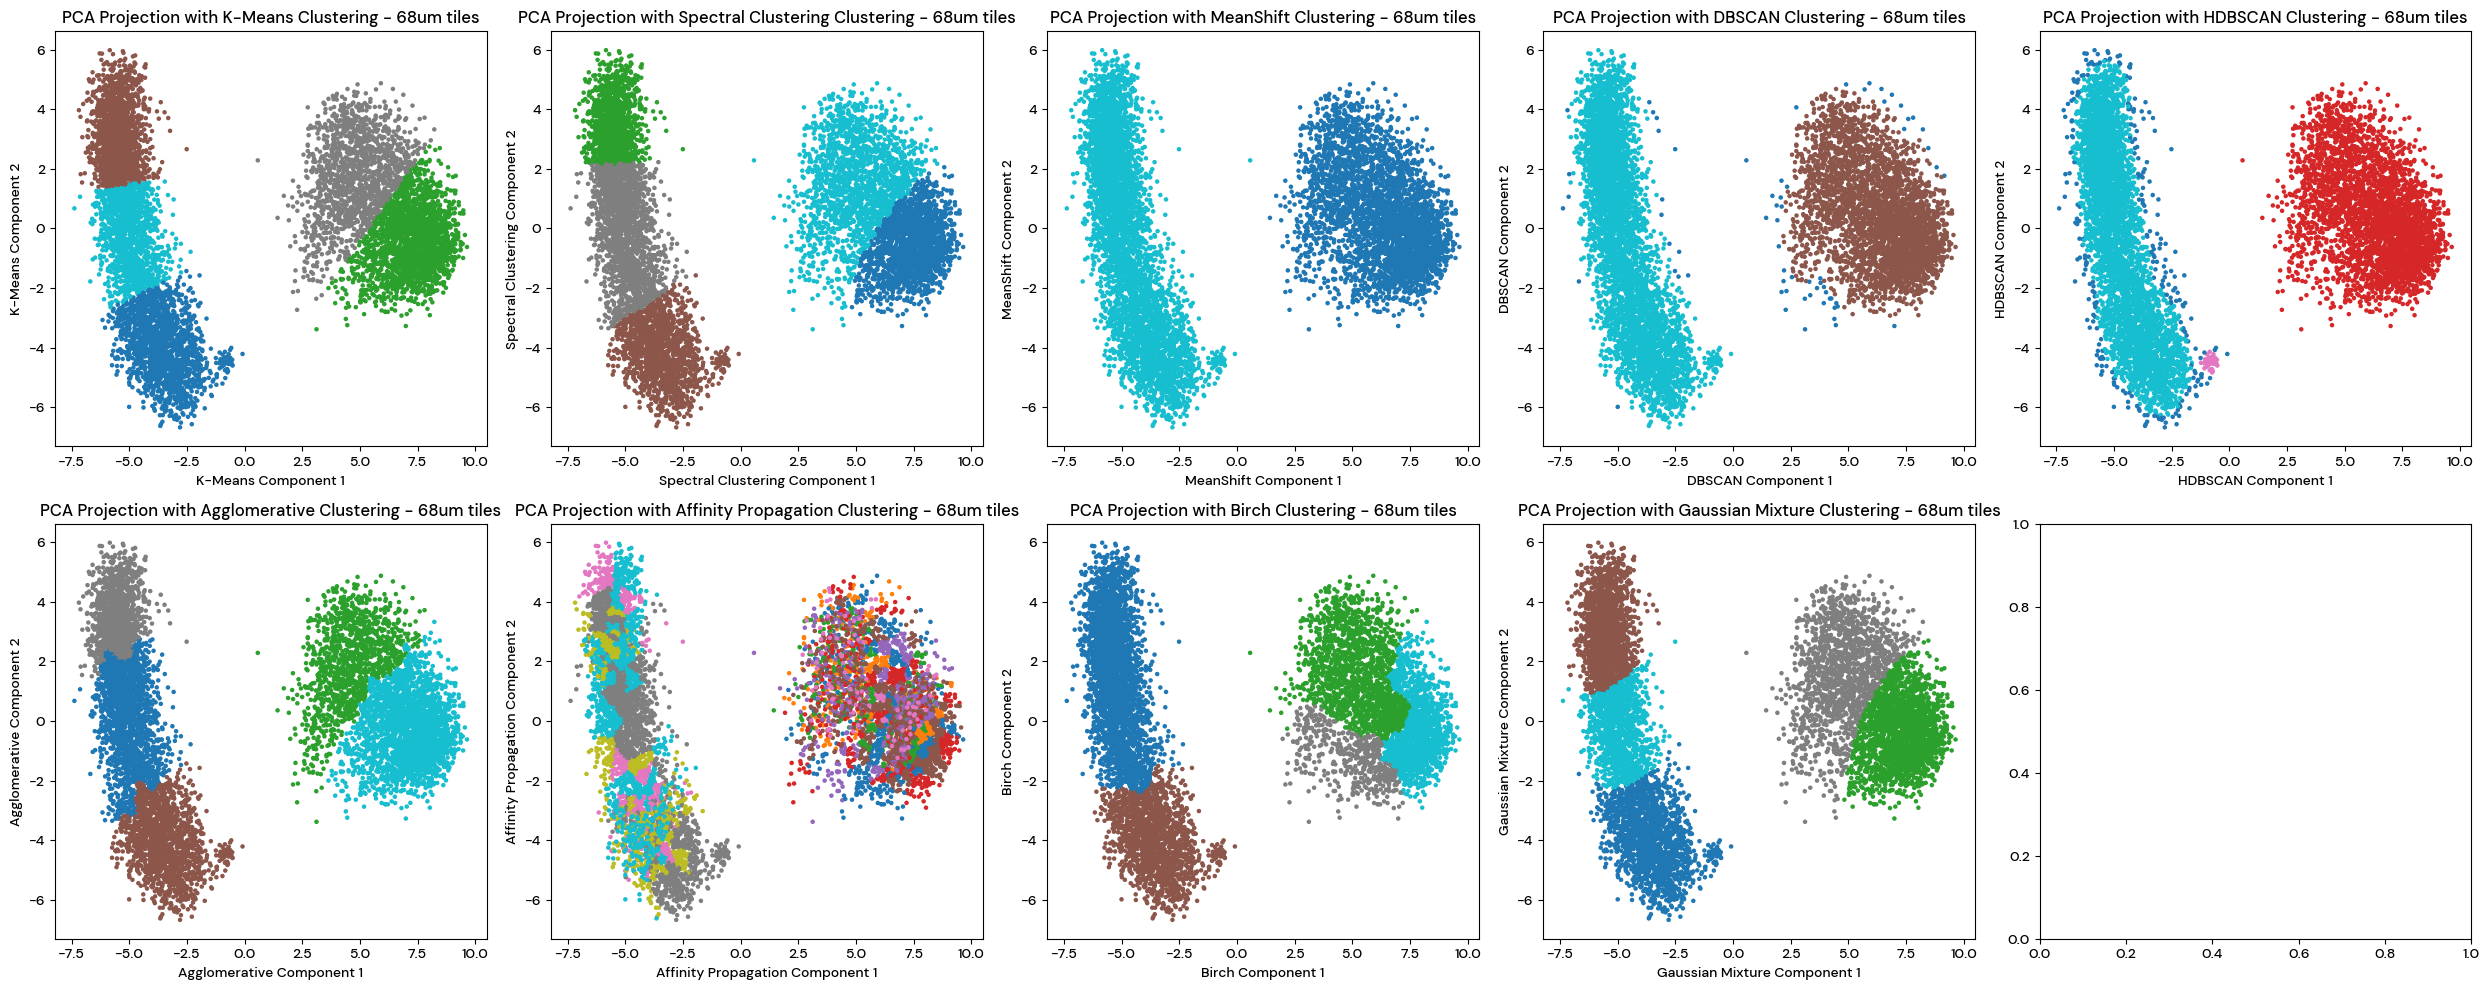

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/tmp/ipykernel_218460/1340331449.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


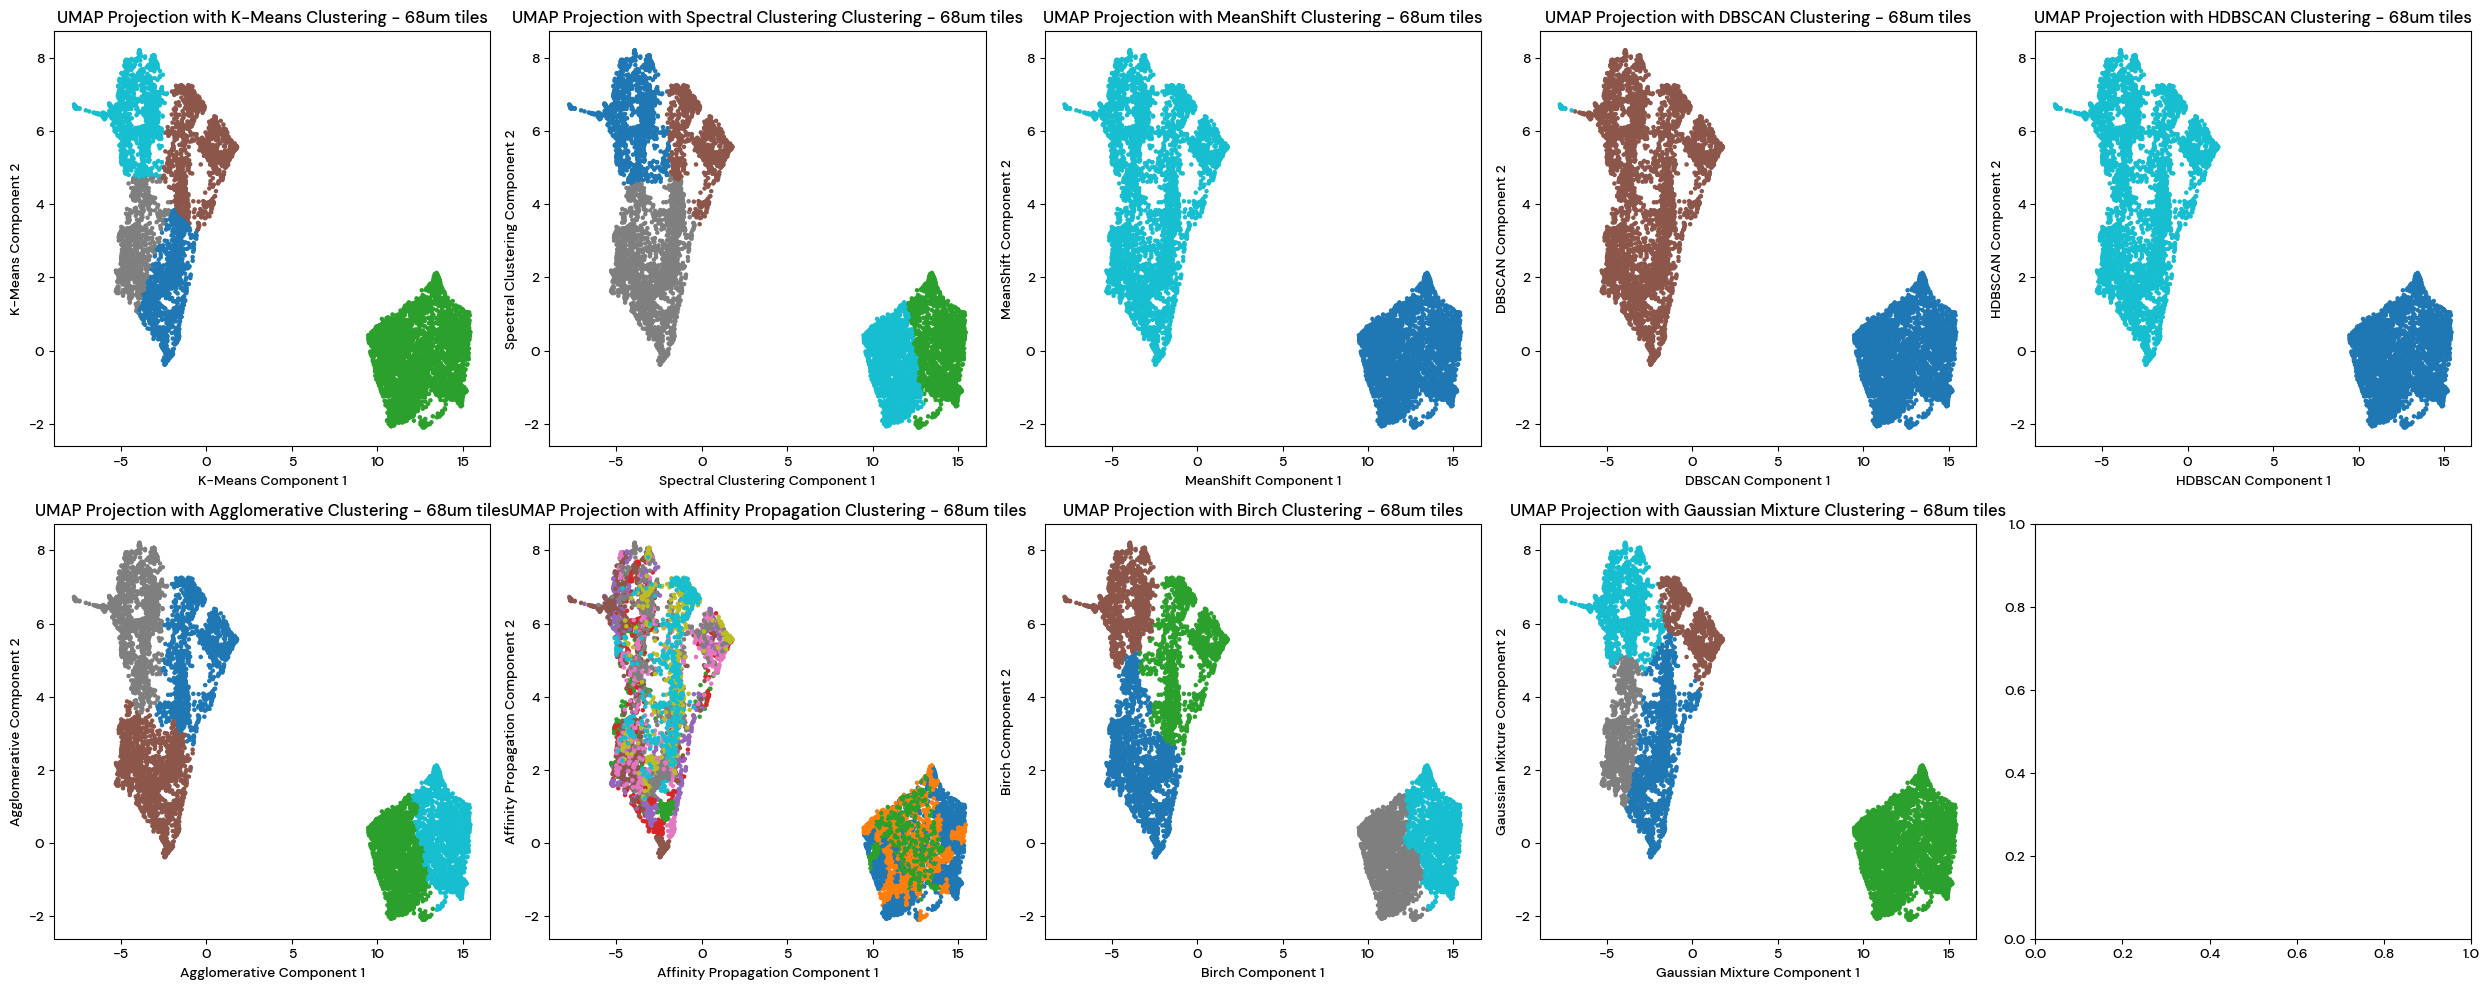

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_218460/1340331449.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


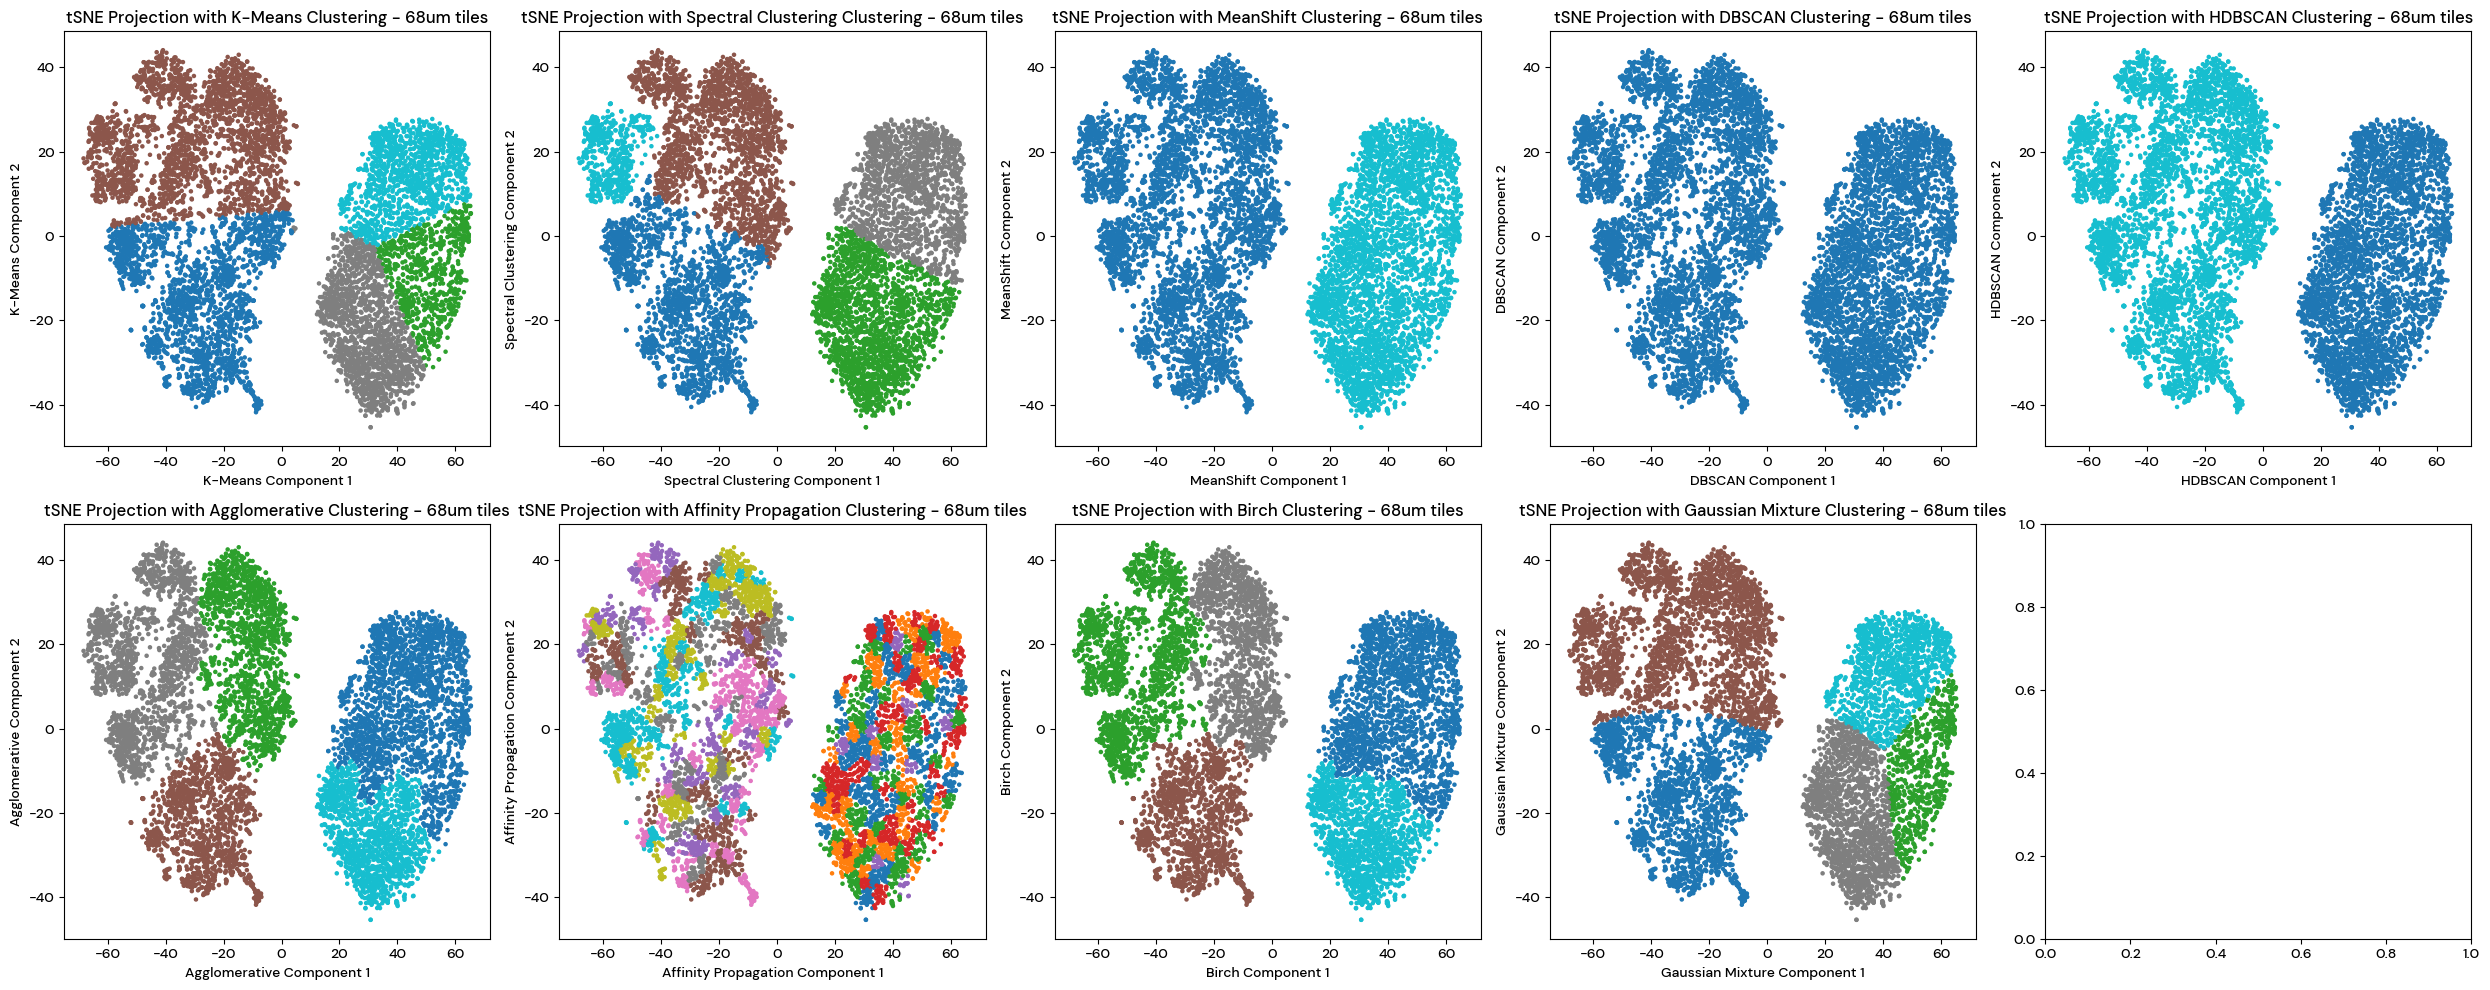

In [19]:
import math
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, HDBSCAN, MeanShift, estimate_bandwidth, SpectralClustering, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture


clustering_methods = [
    ("K-Means", KMeans(n_clusters=5, random_state=123)),
    ("Spectral Clustering", SpectralClustering(n_clusters=5, affinity='nearest_neighbors', n_neighbors=10, 
                                               eigen_solver='arpack', random_state=123)),
    ("MeanShift", MeanShift()),  # bandwidth will be estimated later
    ("DBSCAN", DBSCAN(eps=0.5, min_samples=20)),
    ("HDBSCAN", HDBSCAN(min_cluster_size=20)),
    ("Agglomerative", AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')),
    ("Affinity Propagation", AffinityPropagation(preference=-50)),  # Adjust preference as needed
    ("Birch", Birch(threshold=0.5, n_clusters=5)),  # Adjust threshold as needed
    ("Gaussian Mixture", GaussianMixture(n_components=5, random_state=123))
]

n_methods = len(clustering_methods)
rows = 2
cols = math.ceil(n_methods / rows)

for tech in dim_red_results_100.keys():
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=True)
    
    for i, (method_name, model) in enumerate(clustering_methods):
        # Estimate bandwidth if using MeanShift
        if method_name == "MeanShift":
            est_band = estimate_bandwidth(dim_red_results_100[tech])
            model.set_params(bandwidth=est_band)
        
        

        # Compute row and col indices
        row, col = divmod(i, cols)
        
        # Fit the clustering model and predict labels
        cluster_labels = model.fit_predict(dim_red_results_100[tech])
        
        # Plot in the appropriate subplot
        ax = axes[row, col]  # Access subplot by row and column
        scatter = ax.scatter(dim_red_results_100[tech][:, 0], dim_red_results_100[tech][:, 1], c=cluster_labels, s=5, cmap='tab10')
        ax.set_title(f"{tech} Projection with {method_name} Clustering - 68um tiles")
        ax.set_xlabel(f'{method_name} Component 1')
        ax.set_ylabel(f'{method_name} Component 2')
    
    plt.tight_layout()
    plt.show()

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/tmp/ipykernel_218460/3630633589.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


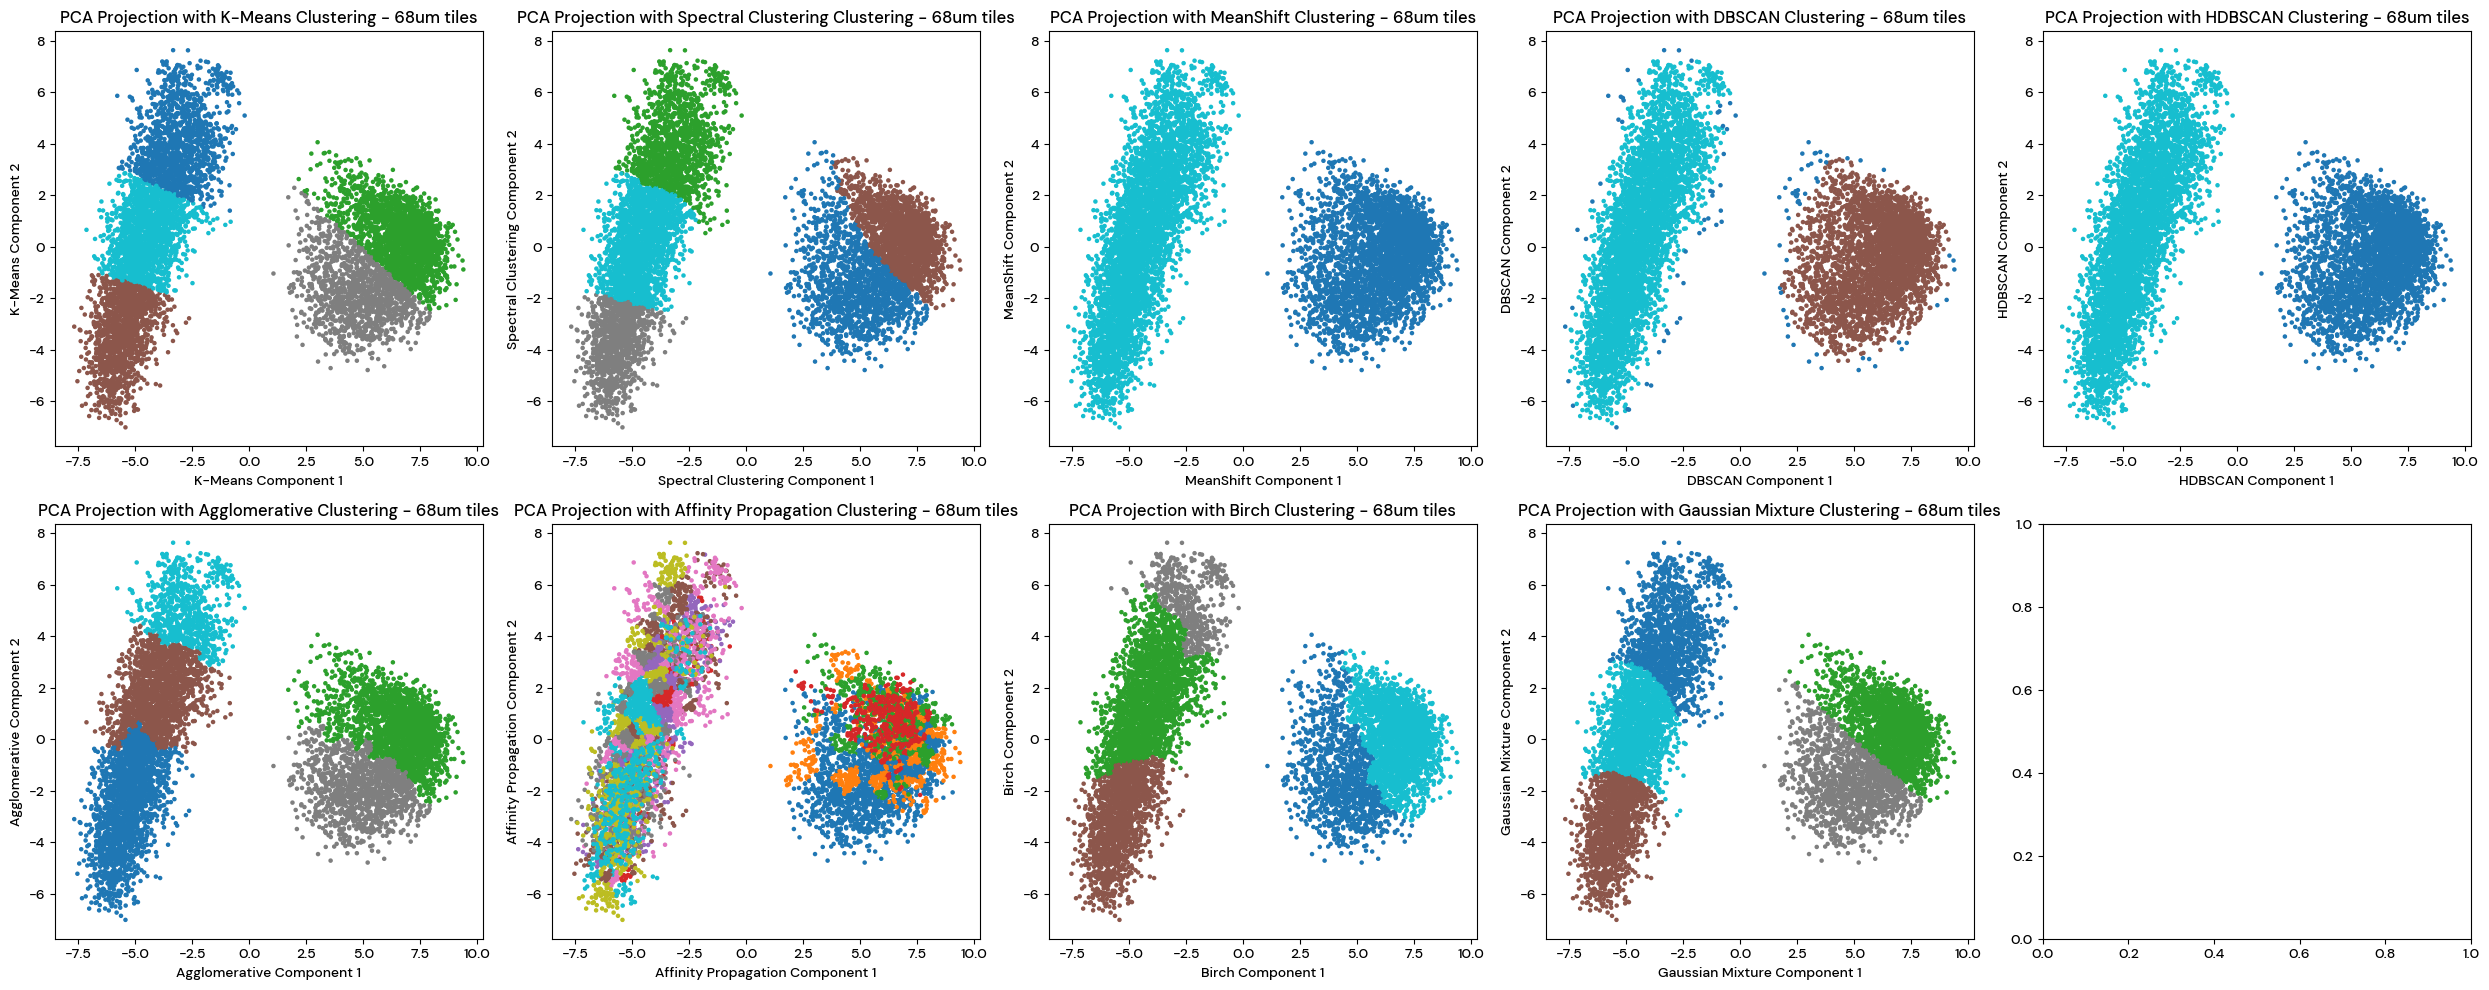

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
/tmp/ipykernel_218460/3630633589.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


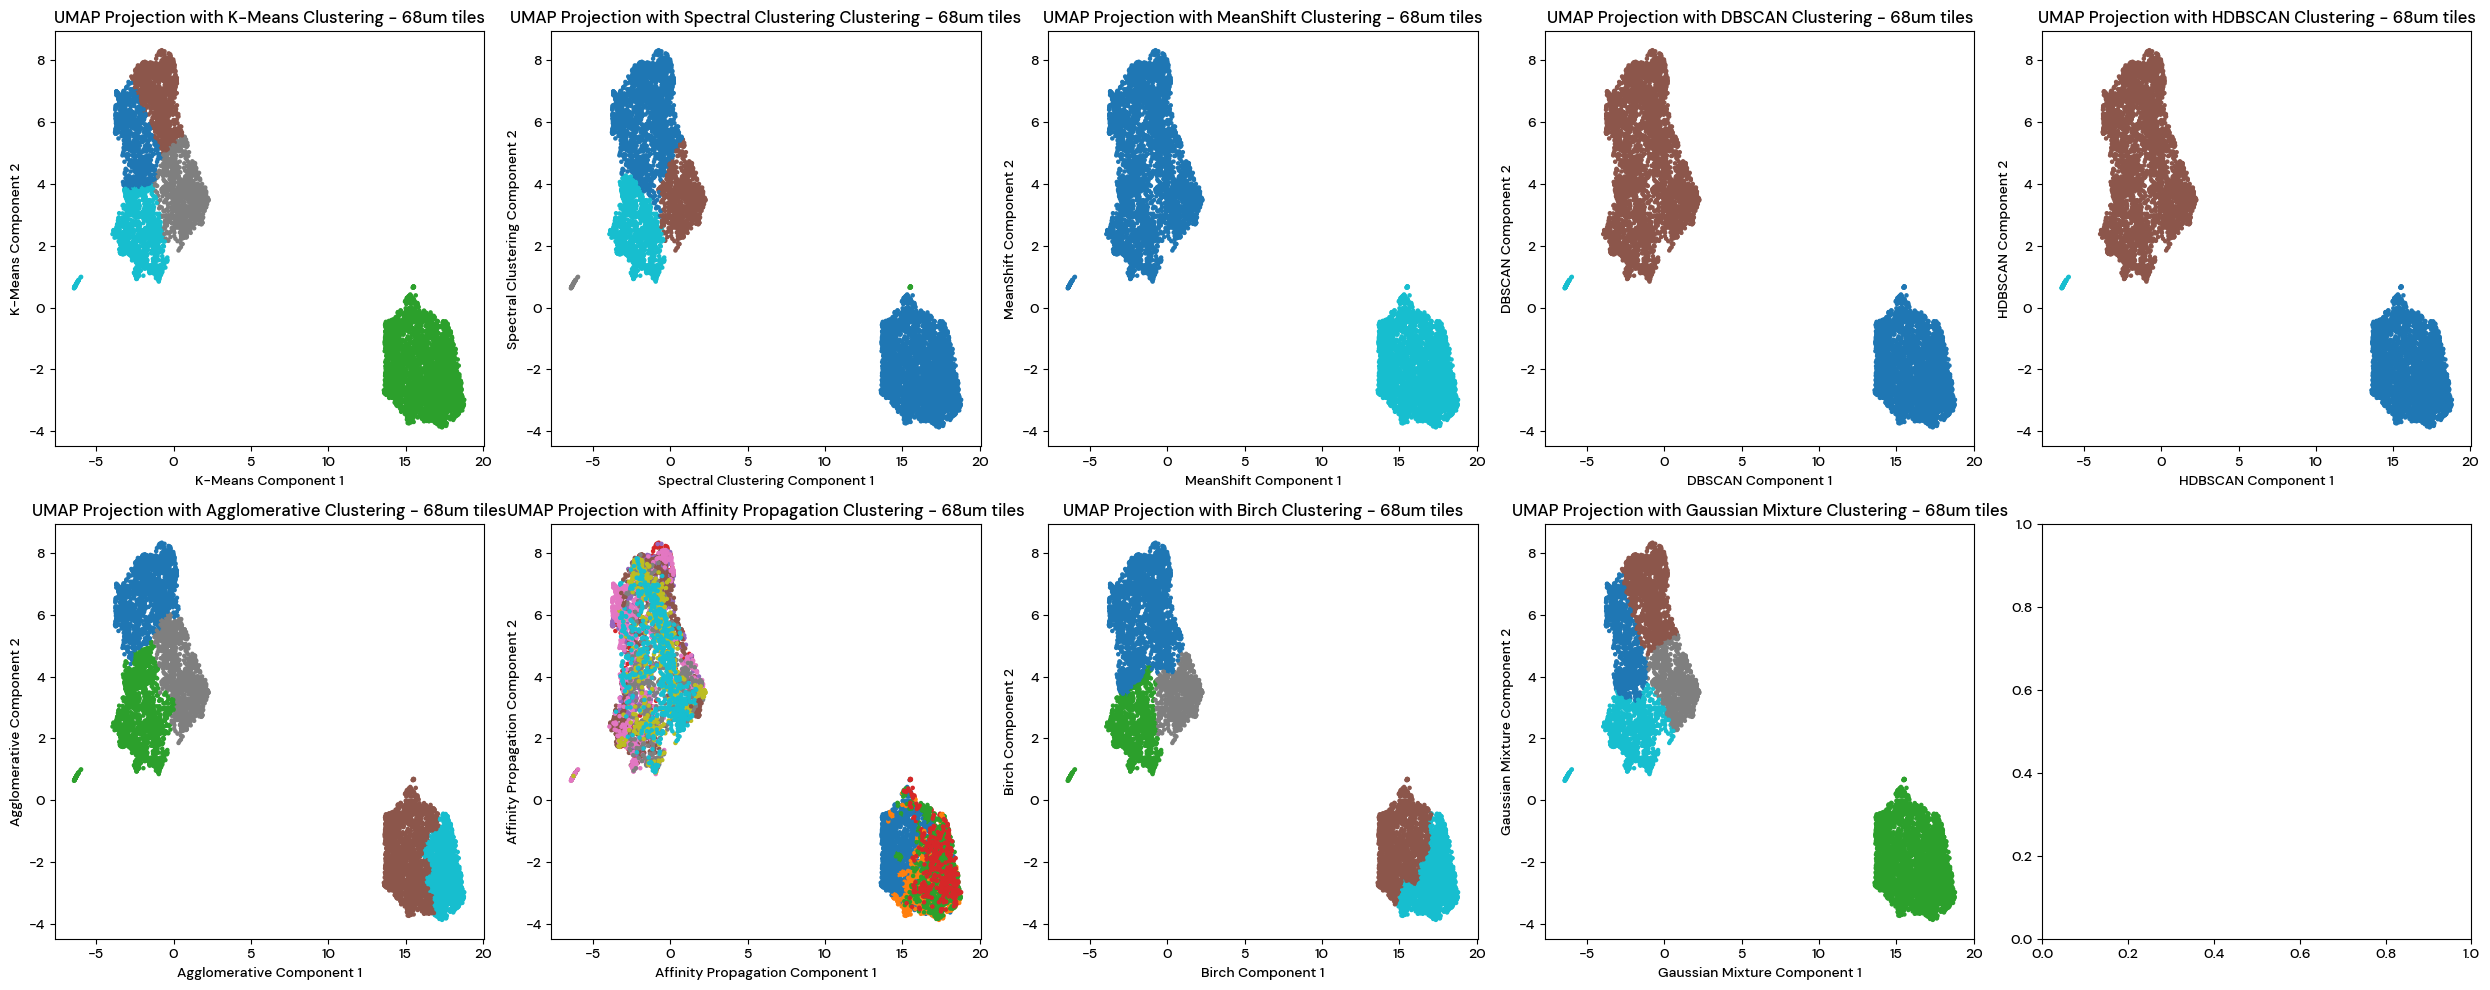

/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_218460/3630633589.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


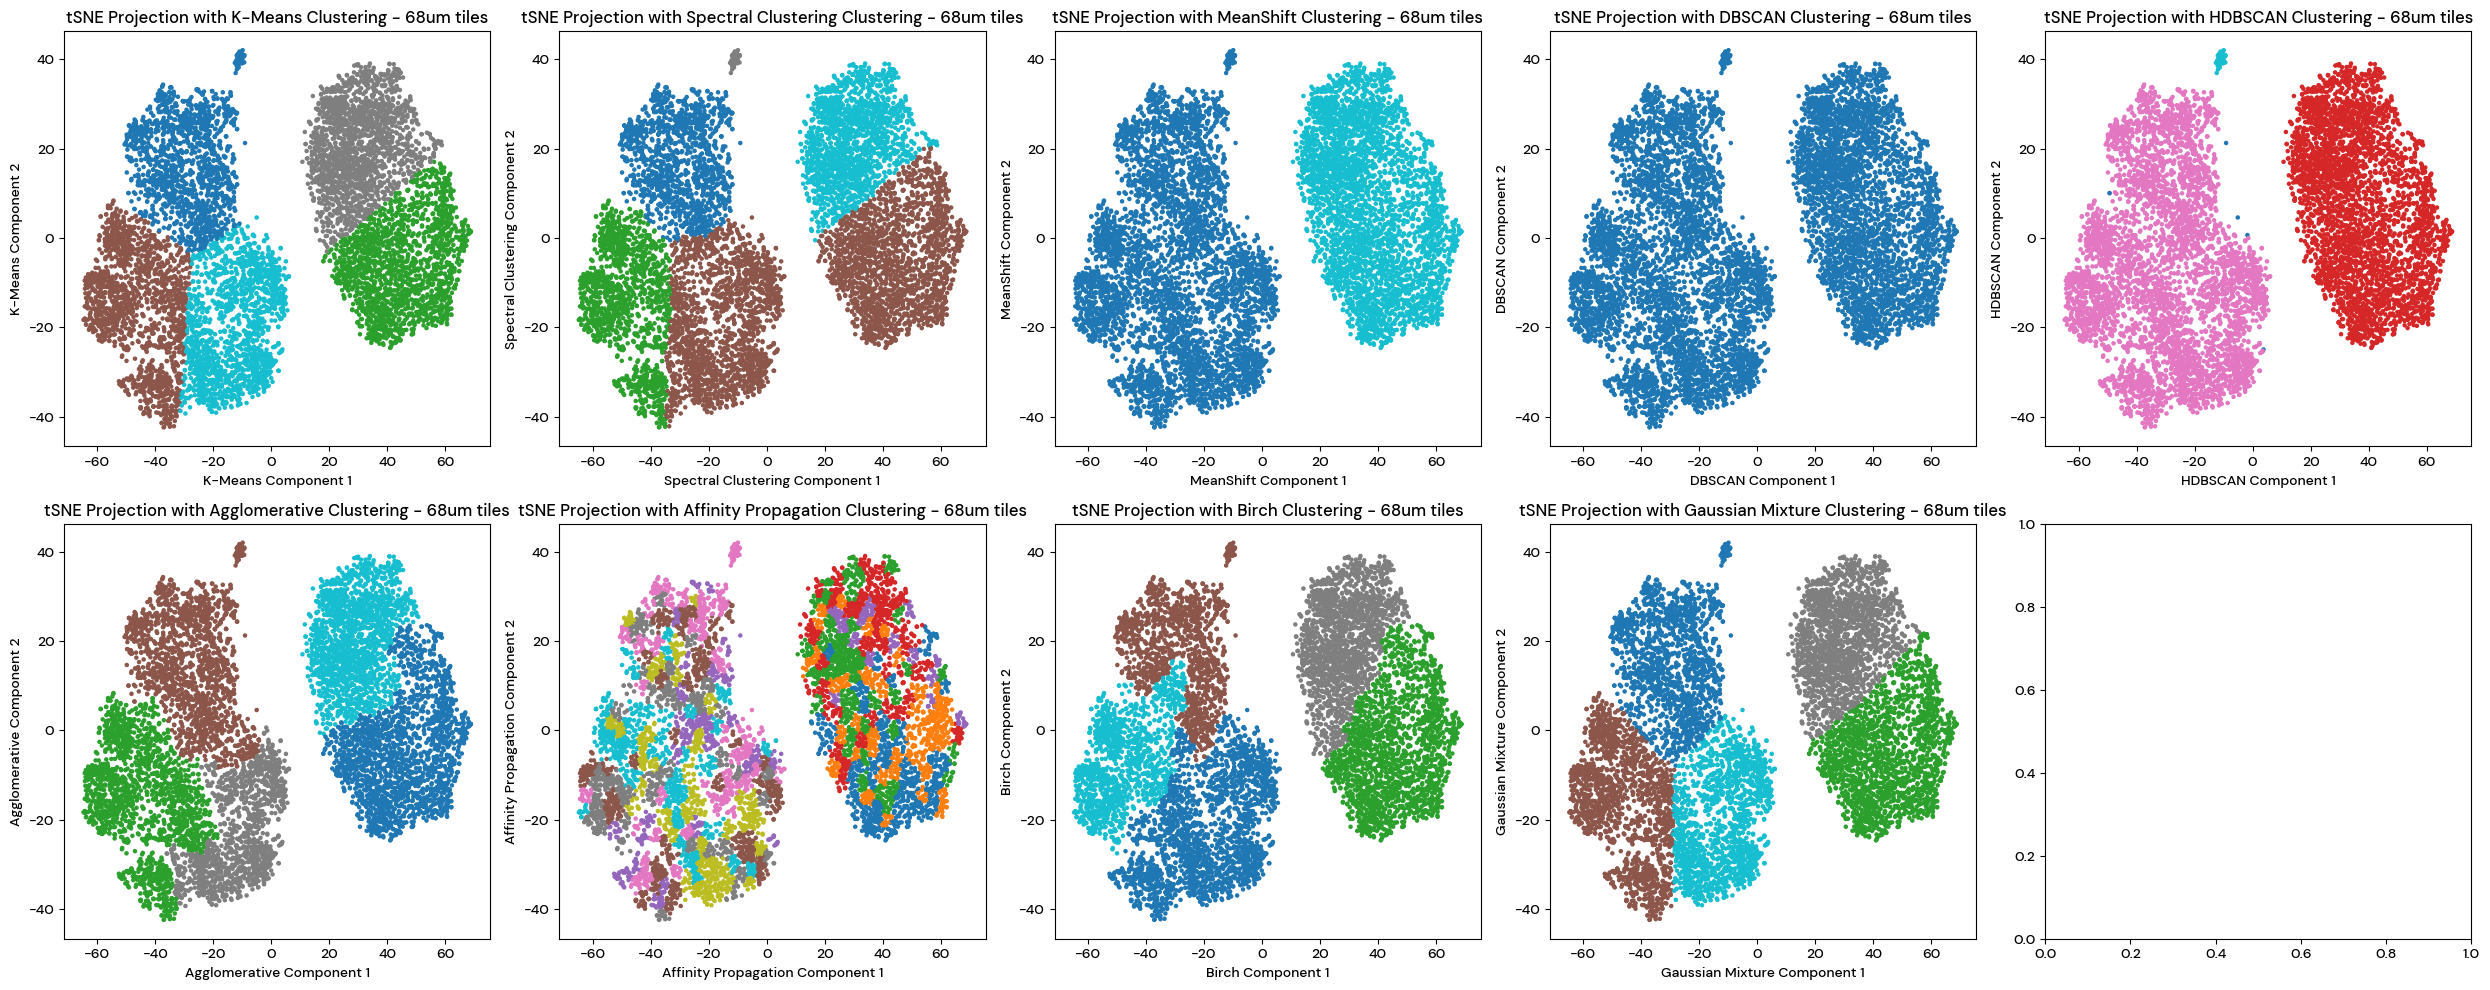

In [20]:
import math
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, HDBSCAN, MeanShift, estimate_bandwidth, SpectralClustering, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture


clustering_methods = [
    ("K-Means", KMeans(n_clusters=5, random_state=123)),
    ("Spectral Clustering", SpectralClustering(n_clusters=5, affinity='nearest_neighbors', n_neighbors=10, 
                                               eigen_solver='arpack', random_state=123)),
    ("MeanShift", MeanShift()),  # bandwidth will be estimated later
    ("DBSCAN", DBSCAN(eps=0.5, min_samples=20)),
    ("HDBSCAN", HDBSCAN(min_cluster_size=20)),
    ("Agglomerative", AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')),
    ("Affinity Propagation", AffinityPropagation(preference=-50)),  # Adjust preference as needed
    ("Birch", Birch(threshold=0.5, n_clusters=5)),  # Adjust threshold as needed
    ("Gaussian Mixture", GaussianMixture(n_components=5, random_state=123))
]

n_methods = len(clustering_methods)
rows = 2
cols = math.ceil(n_methods / rows)

for tech in dim_red_results_68.keys():
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=True)
    
    for i, (method_name, model) in enumerate(clustering_methods):
        # Estimate bandwidth if using MeanShift
        if method_name == "MeanShift":
            est_band = estimate_bandwidth(dim_red_results_68[tech])
            model.set_params(bandwidth=est_band)
        
        

        # Compute row and col indices
        row, col = divmod(i, cols)
        
        # Fit the clustering model and predict labels
        cluster_labels = model.fit_predict(dim_red_results_68[tech])
        
        # Plot in the appropriate subplot
        ax = axes[row, col]  # Access subplot by row and column
        scatter = ax.scatter(dim_red_results_68[tech][:, 0], dim_red_results_68[tech][:, 1], c=cluster_labels, s=5, cmap='tab10')
        ax.set_title(f"{tech} Projection with {method_name} Clustering - 68um tiles")
        ax.set_xlabel(f'{method_name} Component 1')
        ax.set_ylabel(f'{method_name} Component 2')
    
    plt.tight_layout()
    plt.show()

In [21]:
import math
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, HDBSCAN, MeanShift, estimate_bandwidth, SpectralClustering, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture

def plot_clustering_methods(first_2_comp, selected_methods):
    clustering_methods = {
        "K-Means": KMeans(n_clusters=5, random_state=123),
        "Spectral Clustering": SpectralClustering(n_clusters=5, affinity='nearest_neighbors', n_neighbors=10, 
                                                   eigen_solver='arpack', random_state=123),
        "MeanShift": MeanShift(),  # bandwidth will be estimated later
        "DBSCAN": DBSCAN(eps=0.5, min_samples=20),
        "HDBSCAN": HDBSCAN(min_cluster_size=20),
        "Agglomerative": AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward'),
        "Affinity Propagation": AffinityPropagation(preference=-50),  # Adjust preference as needed
        "Birch": Birch(threshold=0.5, n_clusters=5),  # Adjust threshold as needed
        "Gaussian Mixture": GaussianMixture(n_components=5, random_state=123)
    }
    
    selected_clustering_methods = [(name, clustering_methods[name]) for name in selected_methods if name in clustering_methods]
    
    n_methods = len(selected_clustering_methods)
    rows = 2
    cols = math.ceil(n_methods / rows)
    
    for tech in first_2_comp.keys():
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=True)
        
        for i, (method_name, model) in enumerate(selected_clustering_methods):
            # Estimate bandwidth if using MeanShift
            if method_name == "MeanShift":
                est_band = estimate_bandwidth(first_2_comp[tech])
                model.set_params(bandwidth=est_band)
            
            # Compute row and col indices
            row, col = divmod(i, cols)
            
            # Fit the clustering model and predict labels
            cluster_labels = model.fit_predict(first_2_comp[tech])
            
            # Plot in the appropriate subplot
            ax = axes[row, col] if n_methods > 1 else axes  # Handle case when only one plot is needed
            scatter = ax.scatter(first_2_comp[tech][:, 0], first_2_comp[tech][:, 1], c=cluster_labels, s=5, cmap='tab10')
            ax.set_title(f"{tech} Projection with {method_name} Clustering - 68um tiles")
            ax.set_xlabel(f'{method_name} Component 1')
            ax.set_ylabel(f'{method_name} Component 2')
        
        plt.tight_layout()
        plt.show()
        


In [22]:
# from sklearn.cluster import SpectralClustering
# from sklearn.datasets import make_blobs

# # Generate sample data
# X, _ = make_blobs(n_samples=100, centers=3, cluster_std=0.60, random_state=0)

# # Apply Spectral Clustering
# sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', n_init=100)
# labels = sc.fit_predict(X)

# print("Cluster labels:", labels)

---
# 4. - Without empty tiles
Let's perform the same step as above but without the white tiles.

In [23]:
PATH_TO_EMPTY_100um_SATAC = "../1_tiling/output/satac_C1/tiling_output/v3_allspots/original_100um_tiles_with_more_than_50%_white.csv"
PATH_TO_EMPTY_100um_VISIUM = "../1_tiling/output/visium_2022_FF_WG_10X/tiling_output/img_not_changed_allspots/original_100um_tiles_with_more_than_99%_white.csv"

PATH_TO_EMPTY_68um_SATAC = "../1_tiling/output/satac_C1/tiling_output/v3_allspots/original_100um_tiles_with_more_than_50%_white.csv"
PATH_TO_EMPTY_68um_VISIUM = "../1_tiling/output/visium_2022_FF_WG_10X/tiling_output/img_not_changed_allspots/original_100um_tiles_with_more_than_99%_white.csv"

In [24]:
too_white_100um_satac = pd.read_csv(PATH_TO_EMPTY_100um_SATAC, index_col=0)
too_white_100um_visium = pd.read_csv(PATH_TO_EMPTY_100um_VISIUM, index_col=0)

too_white_68um_satac = pd.read_csv(PATH_TO_EMPTY_68um_SATAC, index_col=0)
too_white_68um_visium = pd.read_csv(PATH_TO_EMPTY_68um_VISIUM, index_col=0)

In [25]:
too_white_100um_satac

,Tile name,White percentage
0,GCGATGGCAAACCGTG_row0_col8_100um.jpg,69.721417
1,GTAGCGACATAGTCCG_row11_col11_100um.jpg,50.584209
2,GATGAGGAAATCTCAT_row10_col18_100um.jpg,50.499780
3,CCGAAGACTCTGACGC_row13_col15_100um.jpg,55.533487
4,CAGTCTTTCTAAAGGC_row14_col10_100um.jpg,56.714520
...,...,...
111,AACAAGGGATTAGTGT_row73_col33_100um.jpg,56.852324
112,CTGCCGCTAATCGGGT_row73_col69_100um.jpg,54.603475
113,TAAGGAGATGGTTAAA_row72_col70_100um.jpg,64.655362
114,ACCTCGGGATTCACGG_row75_col87_100um.jpg,64.198605


In [26]:
too_white_100um_visium

,Tile name,White percentage
0,TTACCCATTGCCGGGT-1_row17_col85_100um.jpg,99.105030
1,CCCGACCATAGTCCGC-1_row20_col74_100um.jpg,99.394970
2,GGAAAGTGCCCATGCC-1_row20_col90_100um.jpg,99.053254
3,CTTTAACTTTCAAAGG-1_row23_col67_100um.jpg,99.560651
4,GAATGTTGGGTAATCT-1_row23_col69_100um.jpg,100.000000
...,...,...
67,CACACGCGCTGTCTTA-1_row33_col89_100um.jpg,99.529586
68,TAGACGCCCGTACCGG-1_row32_col90_100um.jpg,100.000000
69,AATCTGCGTTGGGACG-1_row32_col92_100um.jpg,100.000000
70,TCTTTAGCAGGCGAAC-1_row34_col116_100um.jpg,99.143491


Let's remove them.

In [27]:
list(too_white_100um_satac.iloc[:,0])

['GCGATGGCAAACCGTG_row0_col8_100um.jpg',
 'GTAGCGACATAGTCCG_row11_col11_100um.jpg',
 'GATGAGGAAATCTCAT_row10_col18_100um.jpg',
 'CCGAAGACTCTGACGC_row13_col15_100um.jpg',
 'CAGTCTTTCTAAAGGC_row14_col10_100um.jpg',
 'GTGGGTCGAAGGCAGT_row18_col8_100um.jpg',
 'CACGTACAAATAACAG_row20_col10_100um.jpg',
 'CCCTAAATGCCTTACC_row22_col62_100um.jpg',
 'CCACCTGTGTATATTG_row23_col101_100um.jpg',
 'TCACTCCAAGCACGGA_row25_col91_100um.jpg',
 'CTTCACGTTGTGTCCT_row25_col101_100um.jpg',
 'AGTGATGCGAGGCGAT_row25_col103_100um.jpg',
 'CGTATCCTCTGATGTT_row25_col105_100um.jpg',
 'GCCCAAGGGCCGTCAC_row25_col107_100um.jpg',
 'GGCCATGCCTCCCAAG_row25_col109_100um.jpg',
 'GTGTTGTTTGCACGGA_row26_col60_100um.jpg',
 'ATTTCATCGCGACTCT_row26_col90_100um.jpg',
 'ACACAAAGCTTTAAAC_row26_col92_100um.jpg',
 'GTGATCGGAATTGAGT_row26_col96_100um.jpg',
 'CACTGGACTTTCGGTG_row26_col102_100um.jpg',
 'CTGGGTAGCTACAAGG_row26_col108_100um.jpg',
 'GAGAATGATTCTAAGT_row26_col110_100um.jpg',
 'CTAGGCACCTGTACGA_row27_col117_100um.jpg',
 'GC

In [28]:
indices_to_drop_100 = list(too_white_100um_satac.iloc[:, 0]) + list(too_white_100um_visium.iloc[:, 0])
indices_to_drop_100 = [name.replace(".jpg", "") for name in indices_to_drop_100]

# Find indices in the DataFrame that start with any of the names in indices_to_drop_100
matching_indices = [idx for idx in merged_selected_pickle_df_100um.index if any(idx.startswith(name) for name in indices_to_drop_100)]

# Drop the matching rows
without_white_merged_100 = merged_selected_pickle_df_100um.drop(matching_indices, axis=0)
without_white_merged_100

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
AAACAAGGGATCAAAT_row31_col71_100um_stainNET_StainNET.jpg,-0.033423,0.589066,-0.134332,-0.069020,-0.076696,-0.770055,0.012218,-0.395377,0.280108,0.370694,...,-0.274948,0.031574,0.049260,0.373316,-0.221649,-0.278152,-0.725245,-0.557168,-0.431084,0.014018
AAACAGCAGTCTGCTA_row46_col32_100um_stainNET_StainNET.jpg,-0.438272,0.273205,-0.391030,-0.057215,0.302720,-0.709600,-0.267263,-0.959007,0.226993,0.198135,...,-0.300073,-0.171917,0.240682,0.166354,-0.016883,0.287547,-0.368897,-0.573093,0.271210,0.414324
AAACATTCGGGATTCT_row46_col22_100um_stainNET_StainNET.jpg,-0.132595,0.195348,-0.252739,-0.066557,0.105471,-0.523216,-0.112800,-1.029253,0.300439,0.113934,...,0.210925,-0.358305,0.164394,0.142669,-0.077925,-0.021934,-0.442636,-0.470326,-0.280242,-0.042862
AAACCTGGCACACCCT_row21_col33_100um_stainNET_StainNET.jpg,-0.143234,-0.231655,0.384484,-0.004440,-0.030816,-0.353873,-0.085034,-0.404443,0.172420,0.356898,...,-0.464531,-0.241978,0.149451,0.209409,-0.102156,0.031260,-0.475580,-0.494541,-0.248831,0.087503
AAACGCGGCGAAAGTA_row38_col90_100um_stainNET_StainNET.jpg,-0.245308,0.649397,0.018120,-0.097308,0.057878,-0.654822,0.295820,-0.761968,0.448445,0.115693,...,-0.480690,-0.245212,0.269498,0.354504,-0.294617,-0.430894,-0.784309,-0.486899,-0.425926,0.546650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAACGTTTGTATCCAC-1_row77_col123_100um_stainNET.jpg,-0.242982,-0.225248,0.037470,-0.477763,-0.064808,-0.006704,-0.053954,-0.250966,-0.125167,0.348034,...,-0.293400,-0.120338,-0.071854,0.235041,0.527062,-0.431798,-0.104977,0.228352,-0.024887,-0.431920
ATTGAATTCCCTGTAG-1_row76_col124_100um_stainNET.jpg,-0.122449,-0.244053,0.270147,-0.528862,-0.204905,0.306486,-0.346133,-0.008412,-0.169615,0.326014,...,-0.314075,0.139435,0.220631,-0.078413,0.309602,-0.184410,0.217317,0.109952,-0.200411,-0.180295
TACCTCACCAATTGTA-1_row77_col125_100um_stainNET.jpg,0.212932,-0.118300,0.051244,-0.426346,0.033044,0.084312,-0.265475,-0.368785,-0.024039,0.604236,...,-0.716683,-0.098919,-0.045686,0.026671,0.269227,-0.273709,0.136847,-0.031060,-0.167785,-0.084030
AGTCGAATTAGCGTAA-1_row76_col126_100um_stainNET.jpg,0.020303,-0.248056,-0.494349,-0.614175,-0.128167,0.282570,-0.026601,0.143749,0.149249,0.233423,...,-0.361746,-0.015916,0.242655,0.133647,0.196889,-0.574575,0.163836,-0.101484,-0.185461,-0.339206


In [29]:
indices_to_drop_68 = list(too_white_68um_satac.iloc[:, 0]) + list(too_white_68um_visium.iloc[:, 0])
indices_to_drop_68 = [name.replace(".jpg", "") for name in indices_to_drop_68]

# Find indices in the DataFrame that start with any of the names in indices_to_drop_100
matching_indices = [idx for idx in merged_selected_pickle_df_68um.index if any(idx.startswith(name) for name in indices_to_drop_68)]

# Drop the matching rows
without_white_merged_68 = merged_selected_pickle_df_68um.drop(matching_indices, axis=0)
without_white_merged_68

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
CCGACCACCCTACGCG_row0_col0_68um_stainNET.jpg,-0.040355,0.011176,-0.171505,-0.117437,0.134034,-0.336765,-0.045594,-0.856168,0.329597,0.410358,...,-0.399251,-0.239350,-0.033303,0.048765,-0.016210,0.147360,-0.434779,-0.182371,0.065934,0.223421
AAGCCATAGTCGCGAC_row1_col1_68um_stainNET.jpg,-0.103129,0.462296,-0.107971,-0.142071,-0.002877,-0.670711,-0.067777,-0.563453,0.014459,0.189354,...,-0.110098,-0.314159,-0.329310,0.272559,-0.109740,0.135087,-0.217231,-0.251885,-0.491141,0.068081
TTGGGCGGACCGAAGC_row0_col2_68um_stainNET.jpg,-0.181745,0.402894,-0.093540,-0.089285,0.069179,-0.526511,-0.194443,-0.559690,0.300501,0.386626,...,-0.112141,-0.283085,0.230143,0.163252,-0.087932,0.276198,-0.751155,-0.325760,-0.208081,0.316896
AGTAAAGCGCATAATC_row1_col3_68um_stainNET.jpg,0.045683,0.068425,0.096123,-0.220025,0.046298,-0.192836,-0.085324,-0.785023,0.170747,0.389506,...,-0.565123,-0.509336,0.509911,0.237162,-0.046933,-0.167851,-0.573617,-0.616527,-0.398092,0.247451
CGACTCCGCCGATCAA_row0_col4_68um_stainNET.jpg,0.061904,-0.028368,-0.073345,-0.092944,-0.105242,-0.491636,-0.298038,-0.593388,0.158413,0.493568,...,-0.316278,-0.263120,-0.117282,-0.033270,-0.003127,0.644558,-0.462808,-0.100288,0.064103,0.493400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAACGTTTGTATCCAC-1_row77_col123_68um_stainNET.jpg,-0.143662,-0.236313,0.128083,-0.481719,-0.149313,0.278736,0.101727,-0.526610,-0.013165,0.352144,...,-0.215301,0.199000,-0.113871,0.004820,0.711469,-0.457423,-0.234282,0.407757,0.027801,-0.387440
ATTGAATTCCCTGTAG-1_row76_col124_68um_stainNET.jpg,0.142770,-0.091220,0.316282,-0.456328,-0.396570,0.668778,-0.237985,-0.193691,-0.191261,0.163772,...,-0.432204,0.103499,0.330613,0.047905,0.092867,-0.271585,0.059624,0.144185,-0.372395,-0.305542
TACCTCACCAATTGTA-1_row77_col125_68um_stainNET.jpg,-0.002641,0.005236,-0.000347,-0.376102,-0.006546,0.498949,0.047254,-0.186537,0.247556,0.172678,...,-0.421070,0.303868,0.355581,0.022728,0.286933,-0.380866,0.333274,-0.249877,-0.001432,-0.400348
AGTCGAATTAGCGTAA-1_row76_col126_68um_stainNET.jpg,0.314926,-0.332821,-0.146132,-0.684264,-0.134208,0.171471,-0.192561,-0.179966,0.057774,0.383722,...,-0.223255,-0.027782,0.481445,-0.328975,0.028587,-0.351904,0.408858,-0.085597,-0.208340,0.147586


# 2. - Dimensionality reduction

Let's plot the cumulative variance explained by the most important components.

## 2.1 - For 100 μm tiles

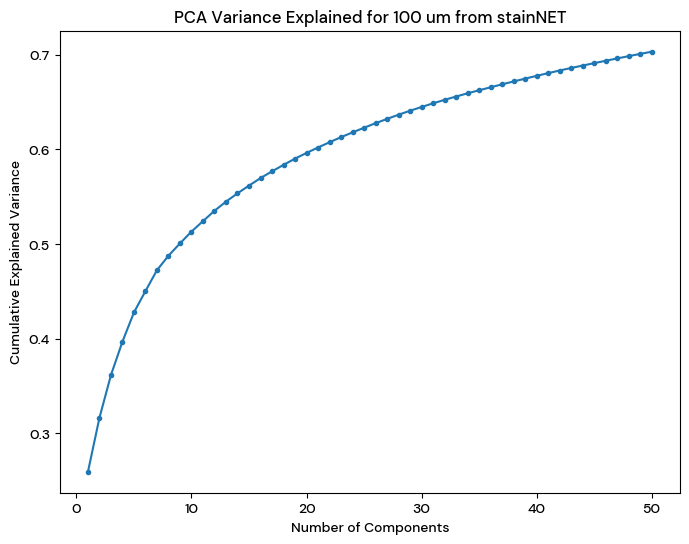

In [30]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot_nowhite = pca_cumulative_variance_plot(without_white_merged_100, normalisation_name, TILE_SIZE)
plot_nowhite.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabga

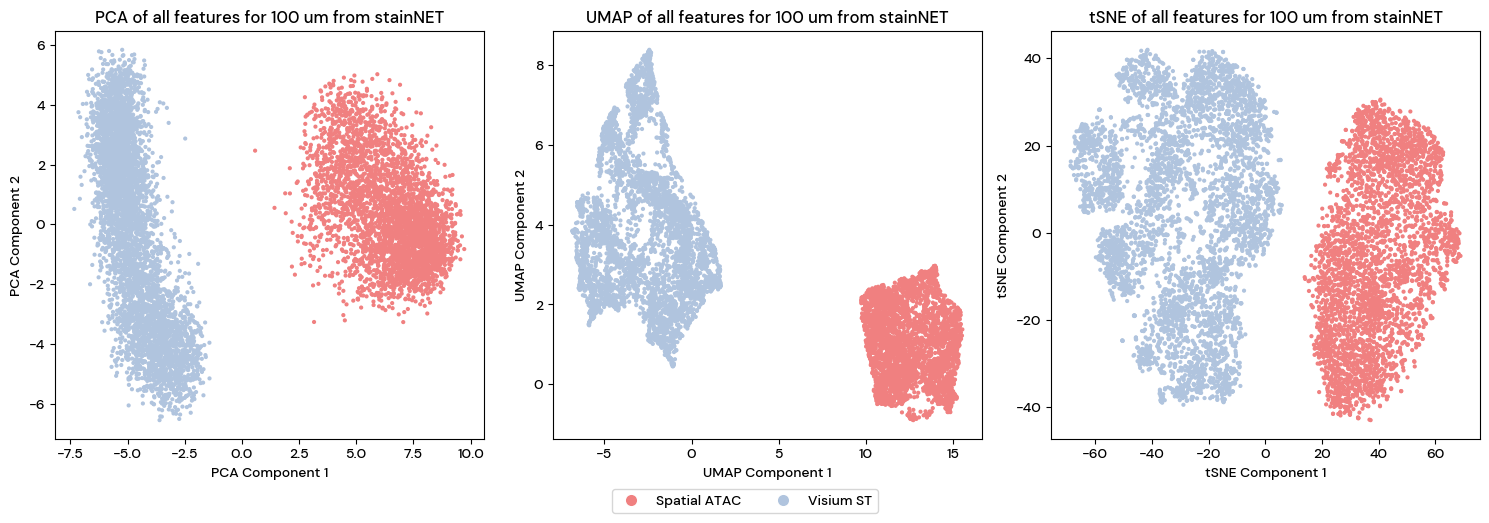

In [31]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot100_nowhite, dim_red_results_100_nowhite =  all_dim_red(without_white_merged_100, normalisation_name, COLORS_FOR_SPATIALS, TILE_SIZE)
plot100_nowhite.show()

In [32]:
# plot100.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{TILE_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"),
#                 format="PDF", bbox_inches='tight')

So, we can say that the normalisation is necessary.

---

## 2.2 - For 68 μm tiles

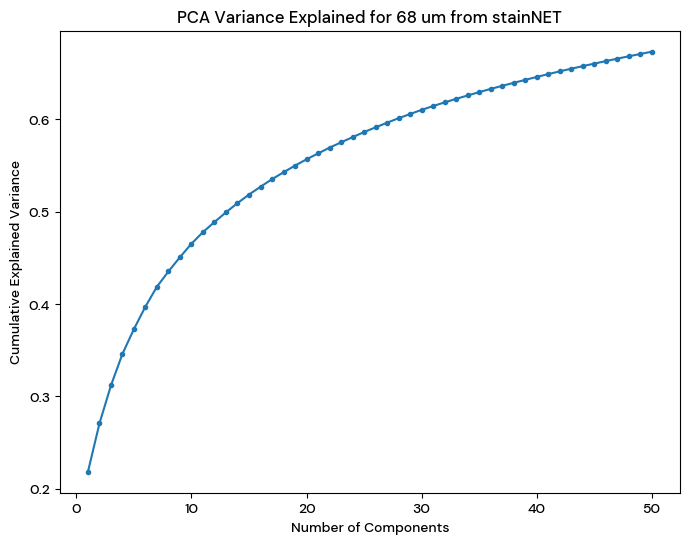

In [33]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot_nowhite = pca_cumulative_variance_plot(without_white_merged_68, normalisation_name, SPOT_SIZE)
plot_nowhite.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')


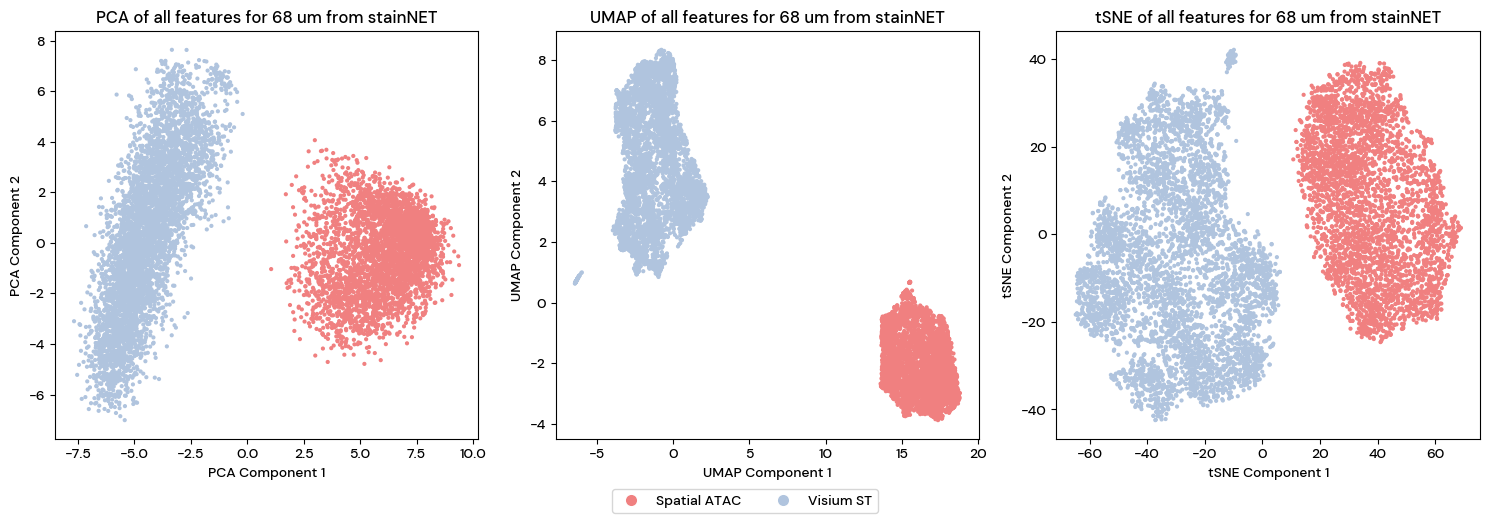

In [34]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot_68_nowhite, dim_red_results_68_nowhite =  all_dim_red(without_white_merged_68, normalisation_name, COLORS_FOR_SPATIALS, SPOT_SIZE)
plot_68_nowhite.show()

In [35]:
# plot_68.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{SPOT_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"), 
#                 format="PDF", bbox_inches='tight')

# 2. - Dimensionality reduction

Let's plot the cumulative variance explained by the most important components.

## 2.1 - For 100 μm tiles

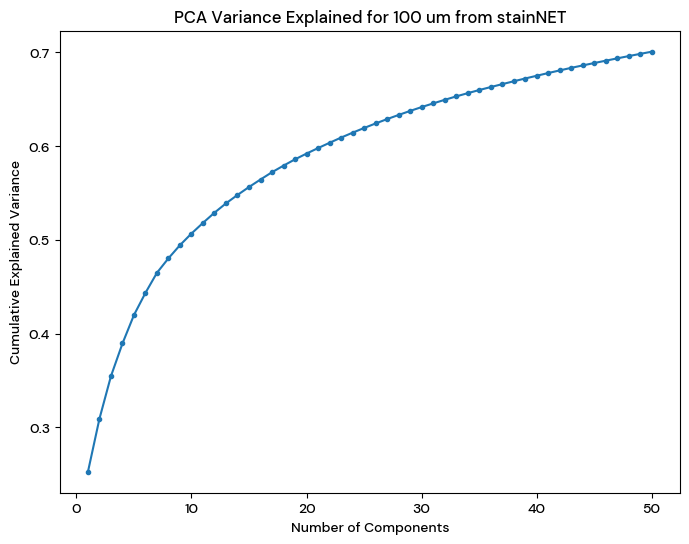

In [36]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot = pca_cumulative_variance_plot(merged_selected_pickle_df_100um, normalisation_name, TILE_SIZE)
plot.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')


/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')


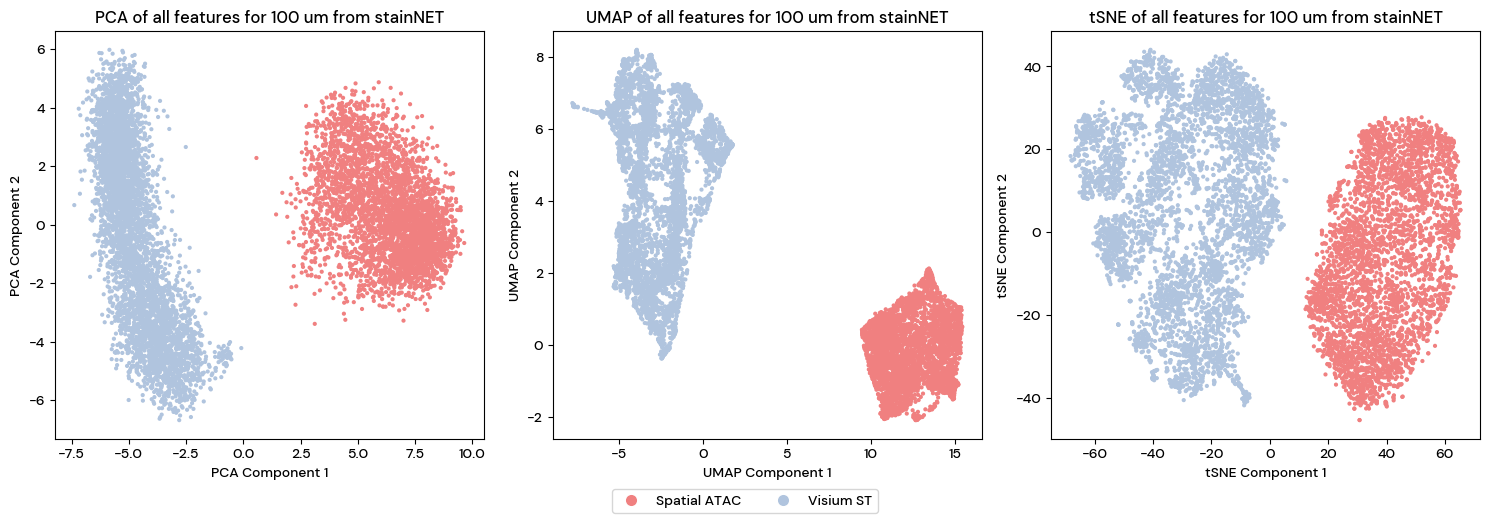

In [37]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot100, dim_red_results_100 =  all_dim_red(merged_selected_pickle_df_100um, normalisation_name, COLORS_FOR_SPATIALS, TILE_SIZE)
plot100.show()

In [38]:
plot100.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{TILE_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"),
                format="PDF", bbox_inches='tight')

So, we can say that the normalisation is necessary.

---

## 2.2 - For 68 μm tiles

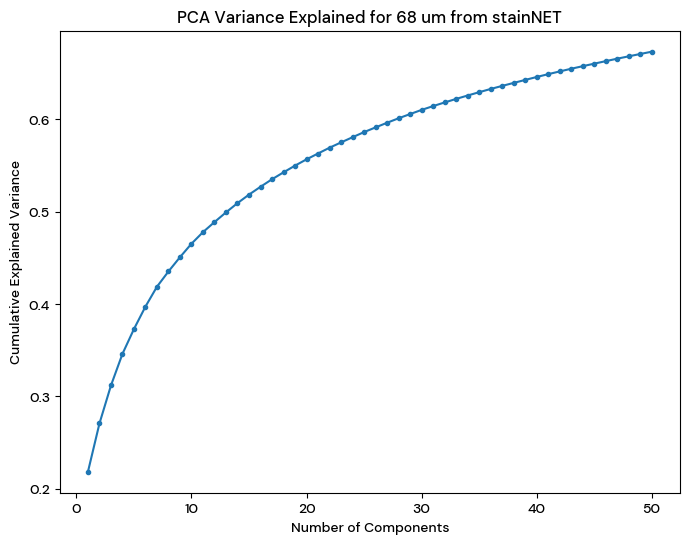

In [39]:
from utils_clust_n_class import pca_cumulative_variance_plot

plot = pca_cumulative_variance_plot(merged_selected_pickle_df_68um, normalisation_name, SPOT_SIZE)
plot.show()

Then let's have a quick visualisation of the PCA, UMAP and tSNE plots.

/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/disk2/user/gabgam/miniconda3/envs/cluster_n_class/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/disk2/work/gabgam/gigi_env/the_project/4_clustering_and_classification/utils_clust_n_class.py:79: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(result[:, 0], result[:, 1], c=colors, s=4, cmap='coolwarm')
/disk2/work/gabga

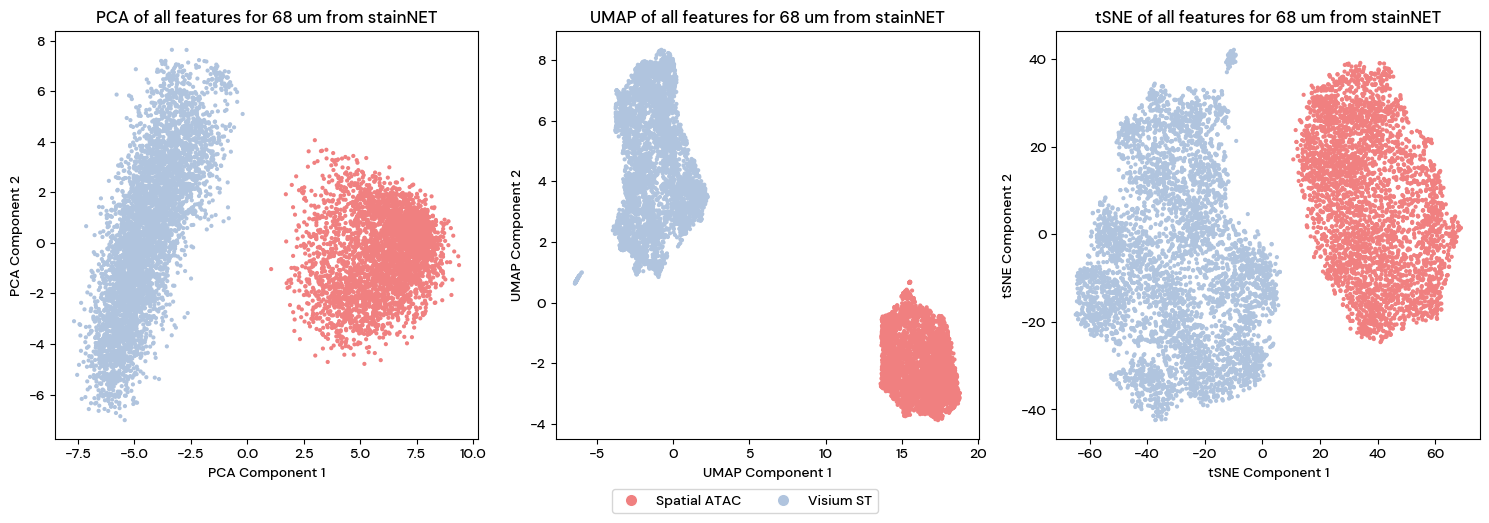

In [40]:
from utils_clust_n_class import all_dim_red

COLORS_FOR_SPATIALS = {"Spatial ATAC": "lightcoral", "Visium ST": "lightsteelblue"}

plot_68, dim_red_results_68 =  all_dim_red(merged_selected_pickle_df_68um, normalisation_name, COLORS_FOR_SPATIALS, SPOT_SIZE)
plot_68.show()

In [41]:
plot_68.savefig(os.path.join(PATH_TO_FIGURES, f"plot_all_dimensionality_reductions_{SPOT_SIZE}um_{normalisation_name.replace(' ', '_')}.pdf"), 
                format="PDF", bbox_inches='tight')